# RIXS from BSE
**by <span style="color:darkgreen">Elias Richter</span>, <span style="color:darkgreen">Benedikt Maurer</span>, and <span style="color:darkgreen">Christian Vorwerk</span> for [<span style="color:darkgoldenrod">exciting *magnesium* </span>](https://www.exciting-code.org)**
<hr style="border:2px solid #DDD"> </hr>

**<span style="color:firebrick">Purpose</span>**: In this tutorial you will learn how to perform a Resonant Inelastic X-ray Scattering (**RIXS**) calculation using prior **BSE** results. As an example, LiF and graphite will be studied.

<hr style="border:2px solid #DDD"> </hr>

<div class="alert alert-block alert-warning">
    
**Table of Contents**

[0. Before Starting](#0)
    
[1. Theoretical Background: Resonant Inelastic X-ray Scattering (RIXS)](#1)
        
[2. Preliminary Step: GS and BSE Calculations](#2)
    
[3. Run BRIXS Calculations](#3)
    
[4. RIXS Cross-Section and Visualisation](#4)
    
[5. Polarisation Resolved RIXS](#5)

[Literature](#6)

</div>

<a id='0'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">0. Before Starting</span>

**<span style="color:firebrick">Read the following paragraphs before starting with the rest of this tutorial!</span>**

As foundation for this tutorial you need to compile **`exciting`** using hdf5. Also, you need to install both  [1] [**BRIXS**](https://github.com/exciting/BRIXS) and [2] [**pyBRIXS**](https://github.com/exciting/pyBRIXS).
For **BRIXS**:
```bash
git clone https://github.com/exciting/BRIXS /path/to/BRIXS
```
change path for hdf5 in **`src/Makefile`** and install with: 
```bash 
cd /path/to/BRIXS
make
make install PREFIX=$HOME/.local
```
The last part is to make **BRIXS** directly reachable instead of adding the path for execution. 


For **pyBRIXS**:
```bash
git clone https://github.com/exciting/pyBRIXS /path/to/pyBRIXS
```
and install with: 
```bash 
cd /path/to/pyBRIXS
python3 -m pip install .
```

Before running any Jupyter tutorials, please refer to the **`00_before_starting.md`** document on how to correctly set up the environment. This only needs to be done once. After which, the **venv** can be (re)activated from **`exciting`**'s root directory:

<div >

```bash
source $EXCITINGROOT/tools/excitingjupyter/venv/excitingvenv/bin/activate
```

</div>

As a first step, you may create a running directory for the notebook.

In [ ]:
%%bash
mkdir -p run_LiF
mkdir -p run_graphite

<a id='1'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">1. Theoretical Background: Resonant Inelastic X-ray Scattering (RIXS)</span>
<details>
<summary><strong><span style="color:firebrick">$\Rightarrow$ Click to show theoretical background!</span></strong></summary>

In **RIXS**, an x-ray photon with energy $\omega_1$ is absorbed, which leads to the
excitation of a core electron to a conduction band. Coherently, an x-ray photon
with energy $\omega_2$ is emitted as a valence electron fills the core hole. The
final state of the scattering process contains a valence hole and an excited
electron in a conduction band. The energy loss $\omega_2-\omega_1$ is
transferred to the electronic system. A schematic representation is given by:

<figure>
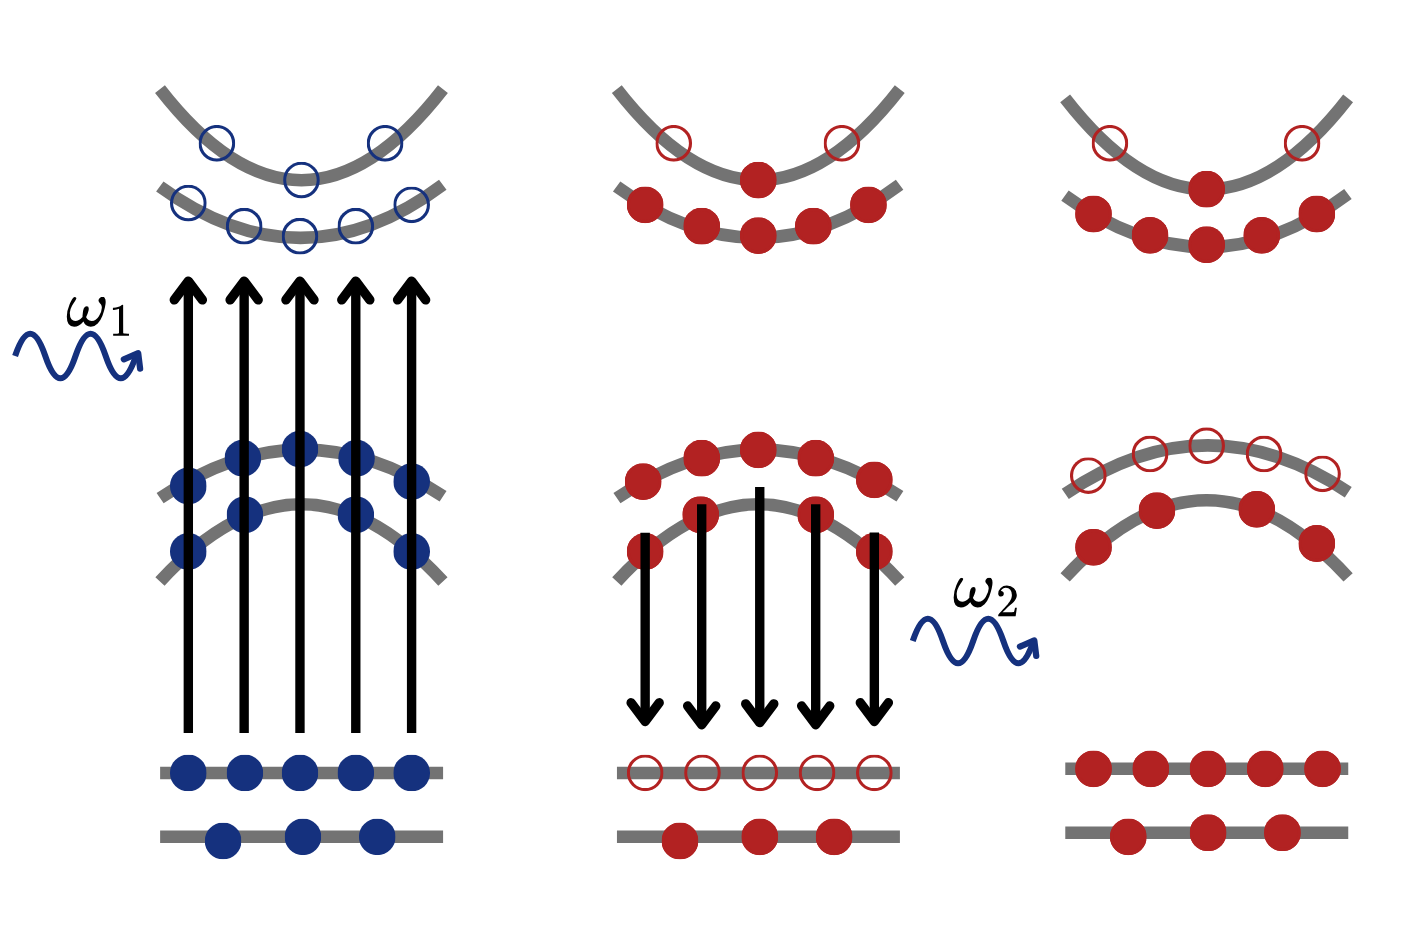
</figure><br>
    
In **RIXS** experiments, the double-differential cross section (DDCS) 
$\mathrm{d}^2 \sigma/\mathrm{d}\Omega_2\mathrm{d}\omega_2$ is measured, 
which describes the rate of scattering for photons with final energy 
$[\omega_2,\omega_2+\mathrm{d}\omega_2]$ in a solid angle range 
$[\Omega_2,\Omega_2+\mathrm{d}\Omega_2]$.

Following the derivation presented in Phys. Rev. 2, 042003(R) (2020), the RIXS
double-differential cross section (DDCS) is defined as

$$
\frac{\mathrm{d}^2 \sigma}{\mathrm{d} \Omega_2 \mathrm{d}\omega_2}= \alpha^4
\left( \frac{\omega_2}{\omega_1} \right) \mathrm{Im} \sum_{\lambda_o}
\frac{|t^{(3)}_{\lambda_o}(\omega_1)|^2}{(\omega_1-\omega_2)-E^{\lambda_o}+\mathrm{i}\eta},
$$

where $E^{\lambda_o}$ are the valence excitation energies of the system, and
$\alpha$ is the fine-structure constant. The DDCS is an explicit function of the
energy loss $\omega_2-\omega_1$, while the oscillator strength
$t^{(3)}_{\lambda_o}(\omega_1)$ depends solely on the excitation energy
$\omega_1$. The oscillator strenght is defined as

$$
t^{(3)}_{\lambda_o}(\omega_1) = \sum_{\lambda_c} \frac{t^{(2)}_{\lambda_o,
\lambda_c}t^{(1)}_{\lambda_c}}{\omega_1-E^{\lambda_c}+\mathrm{i}\eta},
$$
where $E^{\lambda_c}$ are the core excitation energies of the system. The *core
excitation oscillator strength* $t^{(1)}_{\lambda_c}$ is defined as

$$
t^{(1)}_{\lambda_c}=\sum_{c \mu \mathbf{k}} X_{c \mu \mathbf{k},
\lambda_c}\left[ \mathbf{e}_1 \cdot \mathbf{P}_{c \mu \mathbf{k}} \right],
$$
where $X_{c \mu \mathbf{k}, \lambda_c}$ is the **BSE** eigenstate corresponding to
the excitation energy $E^{\lambda_c}$, $\mathbf{e}_1$ is the polarization vector
of the incoming photon, and $\mathbf{P}_{c \mu \mathbf{k}}=\langle c \mathbf{k}
| \hat{\mathbf{p}} | \mu \mathbf{k} \rangle$ are the momentum matrix elements.

The *excitation pathway* $t^{(2)}_{\lambda_o,\lambda_c}$ is defined as
$$
t^{(2)}_{\lambda_o,\lambda_c}=\sum_{c v \mathbf{k}} \sum_{\mu} X_{cv \mathbf{k},
\lambda_o}\left[ \mathbf{e}_2^* \cdot \mathbf{P}_{\mu v \mathbf{k}} \right]
\left[ X_{c \mu \mathbf{k}, \lambda_c} \right]^*,
$$
where $\mathbf{e}_2$ is the polarization vector of the incoming photon. 

<a id='2'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">2. Preliminary Step: GS and BSE Calculations</span>

As a preliminary step to calculate **RIXS** spectra, a groundstate calculation and two **BSE** calculations have to be performed to obtain the core excitation and the valence excitation eigenstates and eigenvalues. In this tutorial we first consider as an example LiF.

### Groundstate

Inside the directory **run_LiF** we create a sub-directory **GS** where we perform the preliminary ground state calculation:

In [ ]:
%%bash
cd run_LiF
mkdir -p GS
cd ..

Inside the **GS** sub-directory we create the input file for LiF. In the <code><span style="color:green">structure</span></code> element we include the lattice parameter and basis vectors of LiF, which has a rock-salt cubic lattice, as well as the positions of the Li and F atoms. In the <code><span style="color:green">groundstate</span></code> element, we include a **2x2x2** **k**-point mesh (<code><span style="color:mediumblue">ngridk</span></code>). 

<span class="LiF_GS"></span>
```xml
<input>
   <title>LiF GS</title>
    
   <structure speciespath="$EXCITINGROOT/species">
   
      <crystal scale="7.60804"> 
         <basevect>0.0 0.5 0.5</basevect> 
         <basevect>0.5 0.0 0.5</basevect> 
         <basevect>0.5 0.5 0.0</basevect> 
      </crystal>
      
      <species speciesfile="Li.xml">
         <atom coord="      0.00000000       0.00000000       0.00000000" />
      </species>
      <species speciesfile="F.xml">
         <atom coord="      0.50000000       0.50000000       0.50000000" />
      </species>
      
  </structure>
  
  <groundstate
     do="fromscratch"
     ngridk="2 2 2"
     xctype="GGA_PBE_SOL"/>
    
</input>
```

In [ ]:
import os
from excitingjupyter.utilities import get_input_xml_from_notebook   

# Extract input file content from this notebook:
input_str = get_input_xml_from_notebook("rixs_from_bse", "LiF_GS")

# Write out the input as an XML file:
with open('./run_LiF/GS/input.xml', "w") as fid:
    fid.write(input_str)

**<span style="color:firebrick">N.B.</span>**: Do not forget to replace the string **"\$EXCITINGROOT"** in **input.xml** by the actual value of the environment variable **\$EXCITINGROOT** by running

In [ ]:
%%bash
cd run_LiF/GS
python3 -m excitingscripts.setup.excitingroot
cd ../..

Now start the groundstate SCF calculation.

In [ ]:
%%bash
cd run_LiF/GS
python3 -m excitingscripts.execute.single
cd ../..

In case of a successful run the files **STATE.OUT** and **EFERMI.OUT** should be present in the directory. These two files are needed as the starting point for the **BSE** calculation.

### F K-edge BSE

We start a **BSE** calculation for the F K-edge absorption spectrum. We do this with the following input file:

<span class="LiF_xas"></span>
```xml
<input>
   <title>LiF F K-edge</title>
    
   <structure speciespath="$EXCITINGROOT/species">
   
      <crystal scale="7.60804"> 
         <basevect>0.0 0.5 0.5</basevect> 
         <basevect>0.5 0.0 0.5</basevect> 
         <basevect>0.5 0.5 0.0</basevect> 
      </crystal>
      
      <species speciesfile="Li.xml">
         <atom coord="      0.00000000       0.00000000       0.00000000" />
      </species>
      <species speciesfile="F.xml">
         <atom coord="      0.50000000       0.50000000       0.50000000" />
      </species>
      
  </structure>
  
  <groundstate
     do="skip"
     ngridk="2 2 2"
     xctype="GGA_PBE_SOL"/>
     
  <xs
     xstype="BSE"
     ngridk="2 2 2"
     ngridq="2 2 2"
     rgkmax="4.0" 
     vkloff="0.05 0.15 0.25"
     nempty="30" 
     gqmax="2.0" 
     broad="0.0276"
     tappinfo="true"
     tevout="true"
     h5fname="core_output.h5">

     <energywindow 
        intv="23.6 24.6" 
        points="1500" />
 
     <screening 
        screentype="full" 
        nempty="100"/>
 
     <BSE 
       chibar0="false"
       chibar0comp="1"
       xas="true"
       xasspecies="2"
	   xasatom="1"
       xasedge="K"
       bsetype="singlet" 
	   nstlxas="1 2"
       brixshdf5="true"/>
 
     <qpointset>
        <qpoint>0.0 0.0 0.0</qpoint>
     </qpointset>
       
     <storeexcitons MinNumberExcitons="1" MaxNumberExcitons="32"/>
   
   </xs>
</input>
```

We see that the 32 lowest-energy excitonic eigenstates are written to file. In a converged **BSE** calculation, the number of eigenstates is huge and one might need to consider carefully how many are necessary for a converged **RIXS** spectrum. Generally, this will depend on the range of excitation energies one is interested in. The higher the excitation energy is beyond the absorption edge, the more eigenstates are required.

We create a separate folder for X-ray absorption calculation, create a new input file and start the calculation.

In [ ]:
%%bash
cd run_LiF
mkdir -p xas && cd xas
cp ../GS/{STATE.OUT,EFERMI.OUT} ./
cd ../..

In [ ]:
import os
from excitingjupyter.utilities import get_input_xml_from_notebook   

# Extract input file content from this notebook:
input_str = get_input_xml_from_notebook("rixs_from_bse", "LiF_xas")

# Write out the input as an XML file:
with open('./run_LiF/xas/input.xml', "w") as fid:
    fid.write(input_str)

In [ ]:
%%bash
cd run_LiF/xas
python3 -m excitingscripts.setup.excitingroot
cd ../..

In [ ]:
%%bash
cd run_LiF/xas
python3 -m excitingscripts.execute.single
cd ../..

### Momentum Matrix Elements

An important ingredient of the **RIXS** calculation are the momentum matrix elements between the core and conduction states. These can be calculated with low computational cost by adjusting the input files such that it looks like:

<span class="LiF_pmat"></span>
```xml
<input>
   <title>LiF pmat</title>
    
   <structure speciespath="$EXCITINGROOT/species">
   
      <crystal scale="7.60804"> 
         <basevect>0.0 0.5 0.5</basevect> 
         <basevect>0.5 0.0 0.5</basevect> 
         <basevect>0.5 0.5 0.0</basevect> 
      </crystal>
      
      <species speciesfile="Li.xml">
         <atom coord="      0.00000000       0.00000000       0.00000000" />
      </species>
      <species speciesfile="F.xml">
         <atom coord="      0.50000000       0.50000000       0.50000000" />
      </species>
      
  </structure>
  
  <groundstate
     do="skip"
     ngridk="2 2 2"
     xctype="GGA_PBE_SOL"/>
     
  <xs
     xstype="BSE"
     ngridk="2 2 2"
     ngridq="2 2 2"
     rgkmax="4.0" 
     vkloff="0.05 0.15 0.25"
     nempty="30" 
     gqmax="2.0" 
     broad="0.0276"
     tappinfo="true"
     tevout="true"
     h5fname="pmat.h5">

     <energywindow 
        intv="23.6 24.6" 
        points="1500" />
 
     <screening 
        screentype="full" 
        nempty="100"/>
 
     <BSE 
        chibar0="false"
        chibar0comp="1"
        xas="true"
        xasspecies="2"
	    xasatom="1"
        xasedge="K"
        bsetype="singlet" 
	    nstlxas="1 2"
        brixshdf5="true" />
 
     <qpointset>
        <qpoint>0.0 0.0 0.0</qpoint>
     </qpointset>
      
     <plan>
        <doonly task="xsgeneigvec"/>
        <doonly task="writepmatxs"/>
        <doonly task="writepmatasc"/> 
     </plan>
     
   </xs>
</input>

```

In [ ]:
%%bash
cd run_LiF
mkdir -p pmat && cd pmat
cp ../GS/{STATE.OUT,EFERMI.OUT} ./
cd ../..

In [ ]:
import os
from excitingjupyter.utilities import get_input_xml_from_notebook   

# Extract input file content from this notebook:
input_str = get_input_xml_from_notebook("rixs_from_bse", "LiF_pmat")

# Write out the input as an XML file:
with open('./run_LiF/pmat/input.xml', "w") as fid:
    fid.write(input_str)

In [ ]:
%%bash
cd run_LiF/pmat
python3 -m excitingscripts.setup.excitingroot
cd ../..

In [ ]:
%%bash
cd run_LiF/pmat
python3 -m excitingscripts.execute.single
cd ../..

### Valence Spectrum

Following the F K-edge spectrum, we now calculate the valence excitation spectrum. While many parameters (such as <code><span style="color:mediumblue">nstlbse</span></code> and <code><span style="color:mediumblue">gqmax</span></code>) can be different between the two **BSE** calculations, the parameters <code><span style="color:mediumblue">ngridk</span></code>, <code><span style="color:mediumblue">ngridq</span></code>, and <code><span style="color:mediumblue">vkloff</span></code> have to be identical. As such, the input file looks like this:

<span class="LiF_val"></span>
```xml
<input>
   <title>LiF Valence Spectrum</title>
    
   <structure speciespath="$EXCITINGROOT/species">
   
      <crystal scale="7.60804"> 
         <basevect>0.0 0.5 0.5</basevect> 
         <basevect>0.5 0.0 0.5</basevect> 
         <basevect>0.5 0.5 0.0</basevect> 
      </crystal>
      
      <species speciesfile="Li.xml">
         <atom coord="      0.00000000       0.00000000       0.00000000" />
      </species>
      <species speciesfile="F.xml">
         <atom coord="      0.50000000       0.50000000       0.50000000" />
      </species>
      
  </structure>
  
  <groundstate
     do="skip"
     ngridk="2 2 2"
     xctype="GGA_PBE_SOL"/>
     
  <xs
     xstype="BSE"
     ngridk="2 2 2"
     ngridq="2 2 2"
     rgkmax="4.0" 
     vkloff="0.05 0.15 0.25"
     nempty="30" 
     gqmax="2.0" 
     broad="0.0276"
     tappinfo="true"
     tevout="true"
     h5fname="optical_output.h5">

     <energywindow 
        intv="0 1.0" 
        points="1500" />

     <screening 
        screentype="full" 
        nempty="100" />

     <BSE
        chibar0="false"
        chibar0comp="1"
        bsetype="singlet" 
        nstlbse="2 5 1 2"
        brixshdf5="true"/>

     <qpointset>
        <qpoint>0.0 0.0 0.0</qpoint>
     </qpointset>
    
     <storeexcitons MinNumberExcitons="1" MaxNumberExcitons="64"/>
       
     <plan>
        <doonly task="writepmatxs"/>
        <doonly task="scrcoulint"/>
        <doonly task="exccoulint"/>
        <doonly task="bse"/>
     </plan>
   
   </xs>
</input>

```

Instead of doing the calculations from scratch, we copy the core absorption results and only redo necessary tasks. 

In [ ]:
%%bash
cd run_LiF
cp -r xas val
cd val && rm input.xml && rm core_output.h5
cd ../..

In [ ]:
import os
from excitingjupyter.utilities import get_input_xml_from_notebook   

# Extract input file content from this notebook:
input_str = get_input_xml_from_notebook("rixs_from_bse", "LiF_val")

# Write out the input as an XML file:
with open('./run_LiF/val/input.xml', "w") as fid:
    fid.write(input_str)

In [ ]:
%%bash
cd run_LiF/val
python3 -m excitingscripts.setup.excitingroot
cd ../..

In [ ]:
%%bash
cd run_LiF/val
python3 -m excitingscripts.execute.single
cd ../..

<a id='3'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">3. Run BRIXS Calculations</span>


We copy the **BSE** results in form of the different **optical_output.h5**, **core_output.h5** and **pmat.h5** files. If the input-option <code><span style="color:mediumblue">h5fname</span></code> is not specified, all files are given by **bse_output.h5** and need to be renamed accordingly. 

In [ ]:
%%bash
cd run_LiF
mkdir -p rixs && cd rixs
cp ../val/optical_output.h5 .
cp ../xas/core_output.h5 .
cp ../pmat/pmat.h5 .
cd ../..

Now we have to create the file **input.cfg** that describes the input parameters for the **BRIXS** calculation. The file contains the following:

<span class="LiF_rixs"></span>
```cfg
omega=653 654 655 656
pol_in=1.0 0.0 0.0
pol_out=1.0 0.0 0.0
broad=0.15
nblocks=1
eigstates_optical=64
eigstates_core=32

```

Here we specify:

**omega**: Excitation energies of the initial X-ray in eV.

**pol_in, pol_out**: Polarization vectors of the incoming and outgoing photons. (Note that the polarization should be identical to the one specified by the parameter chibar0comp in the exciting calculations. For the case chosen here both have to be identical.)

**broad**: Lifetime broadening of the intermediate state in eV. 

**eigstates_optical**: Number of eigenstates saved in the corresponding valence BSE calculation.

**eigstates_core**: Number of eigenstates saved in the corresponding core BSE calculation.

**nblocks**: Number of blocks in which the eigenvectors should be separated. (Good estimate is the number of k-points in one direction.)


In [ ]:
import os
from excitingjupyter.utilities import get_input_cfg_from_notebook   

# Extract input file content from this notebook:
cfg_str = get_input_cfg_from_notebook("rixs_from_bse", "LiF_rixs")

# Write out the input as an cfg file:
with open('./run_LiF/rixs/input.cfg', "w") as fid:
    fid.write(cfg_str)

Finally, we execute the first part of the **RIXS** calculation for the two pathways $t^{(1)}$ and $t^{(2)}$ by executing:

In [ ]:
%%bash
cd run_LiF/rixs
rixs-pathway-serial
cd ../..

which creates the file **data.h5**. Subsequent we execute the **RIXS** pathway $t^{(3)}$ by executing:

In [ ]:
%%bash
cd run_LiF/rixs
rixs-oscstr-serial
cd ../..

The result is stored in a file **rixs.h5**.

<a id='4'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">4. RIXS Cross-Section and Visualisation </span>

Calculation of the **RIXS** cross-section is shifted to a python module named **pyBRIXS**. It offers a convenient way to calculate the cross-section.

We construct an **input-ddcs** file for the calculation of the cross-section:

<span class="LiF_pybrixs"></span>
```cfg
[paths]
folder_paths = .

[settings]
broad = 0.1
eloss_min = -2
eloss_max = 25
eloss_step = 0.05

[exc_energy]
omega = 653, 654, 655, 656
```

We specify in which folder the **rixs.h5** files are, give the final state broadening, the loss energy range, and the excitation energy values. Latter have to be identical to the ones in **input.cfg**.

We also save the **input-ddcs.cfg** file in the rixs folder:

In [ ]:
import os
from excitingjupyter.utilities import get_input_cfg_from_notebook   

# Extract input file content from this notebook:
cfg_str = get_input_cfg_from_notebook("rixs_from_bse", "LiF_pybrixs")

# Write out the input as an cfg file:
with open('./run_LiF/rixs/input-ddcs.cfg', "w") as fid:
    fid.write(cfg_str)

An finally, we calculate the **RIXS** cross section. For our case of only one path, the output file is named <code><span >ddcs_vs_loss</span></code>

In [ ]:
%%bash
cd run_LiF/rixs
pyBRIXS-ddcs
cd ../..

There are several ways to display **RIXS** results such as heat maps. Instea we want to plot the spectra for the different excitation energies as a function of the loss energy. A simple skript to plot is provided in **pyBRIXS**.

In [ ]:
import sys
from pyBRIXS.plots import *

ddcs_LiF='./run_LiF/rixs/ddcs_vs_loss'
omega_LiF = np.array([653, 654, 655, 656])

fig, ax = plt.subplots(figsize=(8, 6))

plot_blocks(ddcs_LiF, ax, labels=omega_LiF, label='RIXS LiF')

plt.show()

##### <a id='5'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">5. Polarisation Resolved RIXS </span>

Up to now we limited our considerations on (<code><span style="color:mediumblue">pol_in</span></code>=<code><span style="color:mediumblue">pol_out</span></code>) cases and **BSE** calulations with (<code><span style="color:mediumblue">chibar0="false"</span></code>). Since here already on the level of **BSE** a specific polarization is required, a generelization is not possible. 
However, in principal, general polarisation vectors are supported in **BRIXS**. Nontheless, the **RIXS** formulas base on the full polarizbility. In order to use different polarisation vectors, we have to use the reduced polarizability by setting <code><span style="color:mediumblue">chibar0="true"</span></code>. 

**<span style="color:firebrick">Note</span>**: This means an approximation, which is only tested for graphite!

Nonetheless, we want to provide a tutorial and consider as an example graphite. Again we start with **GS** and **BSE** calculations.

## Groundstate

We specify the groundstate input for **exciting**, create a GS-folder, the corresponding **input.xml**, and start the calculation.

In [ ]:
%%bash
cd run_graphite
mkdir -p GS
cd ..

<span class="Graph_GS"></span>
```xml
<input>
   <title>Graphite GS</title>

   <structure speciespath="$EXCITINGROOT/species">

      <crystal scale="4.651">
         <basevect>  0.5   0.86602540378  0.0 </basevect>
         <basevect>  0.5  -0.86602540378  0.0 </basevect>
         <basevect>  0.0   0.00000000000  2.705 </basevect>
      </crystal>

      <species speciesfile="C.xml" rmt="1.20">
         <atom coord="1.00000000  0.00000000  0.0"/>
         <atom coord="0.66666667  0.33333333  0.0"/>
         <atom coord="0.66666667  0.33333333  0.5"/>
         <atom coord="0.33333333  0.66666667  0.5"/>
      </species>


   </structure>

   <groundstate
      do="fromscratch"
      xctype="GGA_PBE"
      vdWcorrection="TSvdW"
      ngridk="6 6 2"
      rgkmax="8"
      gmaxvr="25">
   </groundstate>
   
</input>
```

In [ ]:
import os
from excitingjupyter.utilities import get_input_xml_from_notebook   

# Extract input file content from this notebook:
input_str = get_input_xml_from_notebook("rixs_from_bse", "Graph_GS")

# Write out the input as an XML file:
with open('./run_graphite/GS/input.xml', "w") as fid:
    fid.write(input_str)

In [ ]:
%%bash
cd run_graphite/GS
python3 -m excitingscripts.setup.excitingroot
cd ../..

In [ ]:
%%bash
cd run_graphite/GS
python3 -m excitingscripts.execute.single
cd ../..

## C K-edge BSE

We start a **BSE** calculation for the C K-edge absorption spectrum. We do this with the following input file:

<span class="Graph_xas"></span>
```xml
<input>
   <title>Graphite C K-edge</title>
 
   <structure speciespath="$EXCITINGROOT/species">

      <crystal scale="4.651">
         <basevect>  0.5   0.86602540378  0.0 </basevect>
         <basevect>  0.5  -0.86602540378  0.0 </basevect>
         <basevect>  0.0   0.00000000000  2.705 </basevect>
      </crystal>
      
      <species speciesfile="C.xml" rmt="1.20">
         <atom coord="1.00000000  0.00000000  0.0"/>
         <atom coord="0.66666667  0.33333333  0.0"/>
         <atom coord="0.66666667  0.33333333  0.5"/>
         <atom coord="0.33333333  0.66666667  0.5"/>
      </species>  
 
 
   </structure>

   <groundstate
      do="skip"
      xctype="GGA_PBE"
      vdWcorrection="TSvdW"
      ngridk="6 6 2"
      rgkmax="8"
      gmaxvr="25">
   </groundstate>

  <xs
      xstype="BSE" 
      ngridk="3 3 1" 
      ngridq="3 3 1"
      nempty="20"
      vkloff="0.05 0.15 0.25" 
      broad="0.018"
      gqmax="3.5"
      scissor="0.68"
      tevout="true"
      tappinfo="true"
      h5fname="core_output.h5">
 
      <energywindow 
         intv="10.0 12.0" 
         points="1500" />
 
      <screening 
         screentype="full" 
         nempty="100" />
 
      <BSE
         xas="true"
         xasspecies="1"
         xasatom="1"
         xasedge="K"
         bsetype="singlet" 
         nstlxas="1 5" 
         brixshdf5="true"/>

      <qpointset>
         <qpoint>0.0 0.0 0.0</qpoint>
      </qpointset>

      <storeexcitons MinNumberExcitons="1" MaxNumberExcitons="90"/>

   </xs>
</input>
```

**<span style="color:firebrick">Note</span>**: One could also save excitons in a selected energy range. In that case the number of saved excitons need to be checked manually, e.g., <code><span >h5ls optical_output.h5/eigvec-singlet-TDA-BAR-full/0001</span></code> and inserted in the **input.cfg** for **BRIXS**. 

We create a folder for xas, write the input file, and start the calculation.

In [ ]:
%%bash
cd run_graphite
mkdir -p xas && cd xas
cp ../GS/{STATE.OUT,EFERMI.OUT} ./
cd ../..

In [ ]:
import os
from excitingjupyter.utilities import get_input_xml_from_notebook   

# Extract input file content from this notebook:
input_str = get_input_xml_from_notebook("rixs_from_bse", "Graph_xas")

# Write out the input as an XML file:
with open('./run_graphite/xas/input.xml', "w") as fid:
    fid.write(input_str)

In [ ]:
%%bash
cd run_graphite/xas
python3 -m excitingscripts.setup.excitingroot
cd ../..

In [ ]:
%%bash
cd run_graphite/xas
python3 -m excitingscripts.execute.single
cd ../..

### Momentum Matrix Elements

We calculate the momentum matrix elements in a separate folder with the following input file: 

<span class="Graph_pmat"></span>
```xml
<input>
   <title>Graphite pmat</title>
 
   <structure speciespath="$EXCITINGROOT/species">

      <crystal scale="4.651">
         <basevect>  0.5   0.86602540378  0.0 </basevect>
         <basevect>  0.5  -0.86602540378  0.0 </basevect>
         <basevect>  0.0   0.00000000000  2.705 </basevect>
      </crystal>
      
      <species speciesfile="C.xml" rmt="1.20">
         <atom coord="1.00000000  0.00000000  0.0"/>
         <atom coord="0.66666667  0.33333333  0.0"/>
         <atom coord="0.66666667  0.33333333  0.5"/>
         <atom coord="0.33333333  0.66666667  0.5"/>
      </species>  
 
 
   </structure>

   <groundstate
      do="skip"
      xctype="GGA_PBE"
      vdWcorrection="TSvdW"
      ngridk="6 6 2"
      rgkmax="8"
      gmaxvr="25">
   </groundstate>

  <xs
      xstype="BSE" 
      ngridk="3 3 1"
      ngridq="3 3 1"
      nempty="20"
      vkloff="0.05 0.15 0.25" 
      broad="0.018"
      scissor="0.68"
      tevout="true"
      tappinfo="true"
      h5fname="pmat.h5">
 
      <energywindow 
         intv="10.0 12.0" 
         points="1500" />
 
      <screening 
         screentype="full" 
         nempty="100" />
 
      <BSE
         xas="true"
         xasspecies="1"
         xasatom="1"
         xasedge="K"
         bsetype="singlet" 
         nstlxas="1 5" 
         brixshdf5="true"/>

      <qpointset>
         <qpoint>0.0 0.0 0.0</qpoint>
      </qpointset>
      
      <plan>
        <doonly task="xsgeneigvec"/>
        <doonly task="writepmatxs"/>
        <doonly task="writepmatasc"/>
      </plan>

   </xs>

</input>
```

In [ ]:
%%bash
cd run_graphite
mkdir -p pmat && cd pmat
cp ../GS/{STATE.OUT,EFERMI.OUT} ./
cd ../..

In [ ]:
import os
from excitingjupyter.utilities import get_input_xml_from_notebook   

# Extract input file content from this notebook:
input_str = get_input_xml_from_notebook("rixs_from_bse", "Graph_pmat")

# Write out the input as an XML file:
with open('./run_graphite/pmat/input.xml', "w") as fid:
    fid.write(input_str)

In [ ]:
%%bash
cd run_graphite/pmat
python3 -m excitingscripts.setup.excitingroot
cd ../..

In [ ]:
%%bash
cd run_graphite/pmat
python3 -m excitingscripts.execute.single
cd ../..

### Valence Spectrum

And finally we calculate the valence excitation spectrum with the following input file:

<span class="Graph_val"></span>
```xml
<input>
   <title>Graphite Valence Spectrum</title>
 
   <structure speciespath="$EXCITINGROOT/species">

      <crystal scale="4.651">
         <basevect>  0.5   0.86602540378  0.0 </basevect>
         <basevect>  0.5  -0.86602540378  0.0 </basevect>
         <basevect>  0.0   0.00000000000  2.705 </basevect>
      </crystal>
      
      <species speciesfile="C.xml" rmt="1.20">
         <atom coord="1.00000000  0.00000000  0.0"/>
         <atom coord="0.66666667  0.33333333  0.0"/>
         <atom coord="0.66666667  0.33333333  0.5"/>
         <atom coord="0.33333333  0.66666667  0.5"/>
      </species>  
 
 
   </structure>

   <groundstate
      do="skip"
      xctype="GGA_PBE"
      vdWcorrection="TSvdW"
      ngridk="6 6 2"
      rgkmax="8"
      gmaxvr="25">
   </groundstate>

  <xs
      xstype="BSE" 
      ngridk="3 3 1" 
      ngridq="3 3 1"
      nempty="20"
      vkloff="0.05 0.15 0.25" 
      gqmax="3.5"
      broad="0.018"
      tevout="true"
      tappinfo="true"
      h5fname="optical_output.h5">
 
      <energywindow 
         intv="0.0 1.0" 
         points="1500" />
 
      <screening 
         screentype="full" 
         nempty="100" />
 
      <BSE 
	     bsetype="singlet" 
         nstlbse="1 8 1 4"
         brixshdf5="true"/>

      <qpointset>
         <qpoint>0.0 0.0 0.0</qpoint>
      </qpointset>

      <storeexcitons MinNumberExcitons="1" MaxNumberExcitons="288"/>
      <plan>
         <doonly task="writepmatxs"/>
         <doonly task="scrcoulint"/>
         <doonly task="exccoulint"/>
         <doonly task="bse"/>
      </plan>
      
   </xs>
</input>
```

Again, we copy the xas folder and reuse prior results. Otherwise additional tasks <code><span >xsgeneigvec</span></code>, <code><span >writepmatxs</span></code>, <code><span >scrgeneigvec</span></code>, <code><span >scrwritepmat</span></code>, and <code><span >screen</span></code> needs to be performed.

In [ ]:
%%bash
cd run_graphite
cp -r xas val
cd val && rm input.xml && rm core_output.h5
cd ../..

In [ ]:
import os
from excitingjupyter.utilities import get_input_xml_from_notebook   

# Extract input file content from this notebook:
input_str = get_input_xml_from_notebook("rixs_from_bse", "Graph_val")

# Write out the input as an XML file:
with open('./run_graphite/val/input.xml', "w") as fid:
    fid.write(input_str)

In [ ]:
%%bash
cd run_graphite/val
python3 -m excitingscripts.setup.excitingroot
cd ../..

In [ ]:
%%bash
cd run_graphite/val
python3 -m excitingscripts.execute.single
cd ../..

### Run BRIXS 

We want to consider one fixed ingoing polarisation and two different outgoing polarisation. This could characterize an experimental setup. 

We create a folder called rixs with two sub-folders for both polarisations. Subsequent, we specify the input files for **BRIXS**. 

In [ ]:
%%bash
cd run_graphite
mkdir rixs && cd rixs
mkdir -p pol1 && cd pol1
cp ../../xas/core_output.h5 .
cp ../../val/optical_output.h5 .
cp ../../pmat/pmat.h5 .
cd ../
mkdir -p pol2 && cd pol2
cp ../../xas/core_output.h5 .
cp ../../val/optical_output.h5 .
cp ../../pmat/pmat.h5 .
cd ../../..

<span class="Graph_rixs_pol1"></span>
```cfg
omega=284 284.25 284.5 284.75 285 285.25 285.5 285.75 286
pol_in=0.866 0.0 0.5
pol_out=-0.5 0.0 0.866
broad=0.25
nblocks=1
eigstates_optical=288
eigstates_core=90
```

and

<span class="Graph_rixs_pol2"></span>
```cfg
omega=284 284.25 284.5 284.75 285 285.25 285.5 285.75 286
pol_in=0.866 0.0 0.5
pol_out=0.0 1.0 0.0
broad=0.25
nblocks=1
eigstates_optical=288
eigstates_core=90
```

In [ ]:
import os
from excitingjupyter.utilities import get_input_cfg_from_notebook   

# Extract input file content from this notebook:
cfg_str_1 = get_input_cfg_from_notebook("rixs_from_bse", "Graph_rixs_pol1")
cfg_str_2 = get_input_cfg_from_notebook("rixs_from_bse", "Graph_rixs_pol2")

# Write out the input as an XML file:
with open('./run_graphite/rixs/pol1/input.cfg', "w") as fid:
    fid.write(cfg_str_1)
with open('./run_graphite/rixs/pol2/input.cfg', "w") as fid:
    fid.write(cfg_str_2)

We execute the first part of the **BRIXS** calculation and create the files **data.h5**.

In [ ]:
%%bash
cd run_graphite/rixs
cd pol1
rixs-pathway-serial
cd ../
cd pol2
rixs-pathway-serial
cd ../../..

And then we execute the second part of the **BRIXS** calculation and create the final files **rixs.h5**.

In [ ]:
%%bash
cd run_graphite/rixs
cd pol1
rixs-oscstr-serial
cd ../
cd pol2
rixs-oscstr-serial
cd ../../..

Instead of calculating the single **RIXS** spectra, we want to take the average over both outgoing polarisations. We specify the **input-ddcs.cfg** with two paths, automatically triggering the calculation of the average. 

<span class="Graph_pybrixs"></span>
```cfg
[paths]
folder_paths = pol1, pol2

[settings]
broad = 0.25
eloss_min = -2
eloss_max = 25
eloss_step = 0.05

[exc_energy]
omega = 284, 284.25, 284.5, 284.75, 285, 285.25, 285.5, 285.75, 286
```

In order to test the effects of different polarizations, let us also look at the two pure ones. We also specify **input-ddcs.cfg**.

<span class="Graph_pybrixs_single_pol"></span>
```cfg
[paths]
folder_paths = .

[settings]
broad = 0.25
eloss_min = -2
eloss_max = 25
eloss_step = 0.05

[exc_energy]
omega = 284, 284.25, 284.5, 284.75, 285, 285.25, 285.5, 285.75, 286
```

In [ ]:
import os
from excitingjupyter.utilities import get_input_cfg_from_notebook   

# Extract input file content from this notebook:
cfg_str = get_input_cfg_from_notebook("rixs_from_bse", "Graph_pybrixs")
cfg_str_pol = get_input_cfg_from_notebook("rixs_from_bse", "Graph_pybrixs_single_pol")


# Write out the input as an cfg file:
with open('./run_graphite/rixs/input-ddcs.cfg', "w") as fid:
    fid.write(cfg_str)
with open('./run_graphite/rixs/pol1/input-ddcs.cfg', "w") as fid:
    fid.write(cfg_str_pol)
with open('./run_graphite/rixs/pol2/input-ddcs.cfg', "w") as fid:
    fid.write(cfg_str_pol)

We calculate the averaged cross section and the two others as function of the loss energy.

In [ ]:
%%bash
cd run_graphite/rixs
pyBRIXS-ddcs
cd pol1
pyBRIXS-ddcs
cd ../pol2
pyBRIXS-ddcs
cd ../../..

And finally we plot the results. 

In [ ]:
import sys
from pyBRIXS.plots import *

omega_graphite = np.array([284, 284.25, 284.5, 284.75, 285, 285.25, 285.5, 285.75, 286])

ddcs_graphite='./run_graphite/rixs/ddcs_vs_loss_mean'

ddcs_graphite_pol1='./run_graphite/rixs/pol1/ddcs_vs_loss'
ddcs_graphite_pol2='./run_graphite/rixs/pol2/ddcs_vs_loss'

fig, ax = plt.subplots(figsize=(8, 6))

plot_blocks(ddcs_graphite_pol1, ax, labels=omega_graphite, plot_labels=False, label='RIXS graphite pol1', color='green')
plot_blocks(ddcs_graphite_pol2, ax, labels=omega_graphite, plot_labels=False, label='RIXS graphite pol2', color='orange')
plot_blocks(ddcs_graphite, ax, labels=omega_graphite, label='RIXS graphite avg. pol')

plt.show()

##### <a id='5'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">6. Coherence RIXS </span>

It is also possible to calculate coherent **RIXS**. In this case instead of the two **BRIXS** steps **rixs-pathway-serial** and **rixs-oscstr-serial**, only **rixs-coherence-serial** must be executed.¸

**\_calc\_incoherent\_**: Set to *"true"* if **rixs_coherence** is calculated and you are also interested in incoherence contribution. 

<a id='6'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">Literature</span>

[1] BRIXS can be found on its git: [**Git**](https://github.com/exciting/BRIXS/tree/2-pol)  
[2] pyBRIXS can be found on its git: [**Git**](https://github.com/exciting/pyBRIXS/tree/add-plots)  
[3] BRIXS and its implementation is explained in Christian Vorwerk’s dissertation *“Theoretical Spectroscopy of Ga₂O₃”* [**PDF**](https://edoc.hu-berlin.de/server/api/core/bitstreams/f57d8e6d-a3e7-46b6-9517-b50019414393/content).  
[4] More applications can be found in the three corresponding publications:  
&nbsp;&nbsp;&nbsp;&nbsp;• *“All-electron many-body approach to resonant inelastic x-ray scattering”* [**PDF**](https://arxiv.org/pdf/2205.05201)  
&nbsp;&nbsp;&nbsp;&nbsp;• *“Excitation Pathways in Resonant Inelastic X-Ray Scattering of Solids”* [**PDF**](https://arxiv.org/pdf/2002.12876)  
&nbsp;&nbsp;&nbsp;&nbsp;• *“First-principles description of pumped inelastic X-ray scattering: example of K-edge RIXS in graphite”* [**PDF**](https://arxiv.org/pdf/2606.09440)

<hr style="border:2px solid #DDD"> </hr>